# DMP Bridge — Model Comparison (pdfplumber parser)

Comparing three LLM models on structured DMP extraction quality, scored against manually labeled ground truth.

**Samples:** 3–10 (8 documents; samples 1 & 2 excluded — used for prompt development)

In [1]:
MODELS = [
    ("llama3.1:8b",  "llama3.1-8b_pdfplumber_whole_doc"),
    ("llama3.3:70b", "llama3.3-70b_pdfplumber_whole_doc"),
    ("gemma4:e4b",   "gemma4-e4b_pdfplumber_whole_doc"),
]
EXCLUDE = [1, 2]

In [2]:
from dmpbridge.evaluation.evaluate import load_method, micro_prf1, compute_f1_rows, confusion_matrix_df
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

results = {}
summary_rows = []
for display_name, tag in MODELS:
    df, conf, errs = load_method(tag, exclude=EXCLUDE)
    if df is None:
        print(f'{display_name:15s} : no data yet')
        continue
    results[display_name] = {'df': df, 'conf': conf, 'tag': tag}
    m = micro_prf1(conf)
    summary_rows.append({'model': display_name, **m})

summary = pd.DataFrame(summary_rows).set_index('model')

print(f"{'Model':<15}  {'Precision':>10}  {'Recall':>8}  {'F1':>8}")
print('-' * 46)
for name, row in summary.iterrows():
    print(f"{name:<15}  {row['precision']*100:>9.1f}%  {row['recall']*100:>7.1f}%  {row['f1']*100:>7.1f}%")

Model             Precision    Recall        F1
----------------------------------------------
llama3.1:8b           32.3%     80.0%     46.0%
llama3.3:70b          68.9%     81.1%     74.5%
gemma4:e4b            72.4%     78.9%     75.5%


## Overall Comparison

Precision drops when a model over-generates spurious blocks; recall drops when it misses gold items. **F1 balances both — this is the single number to compare models on.**

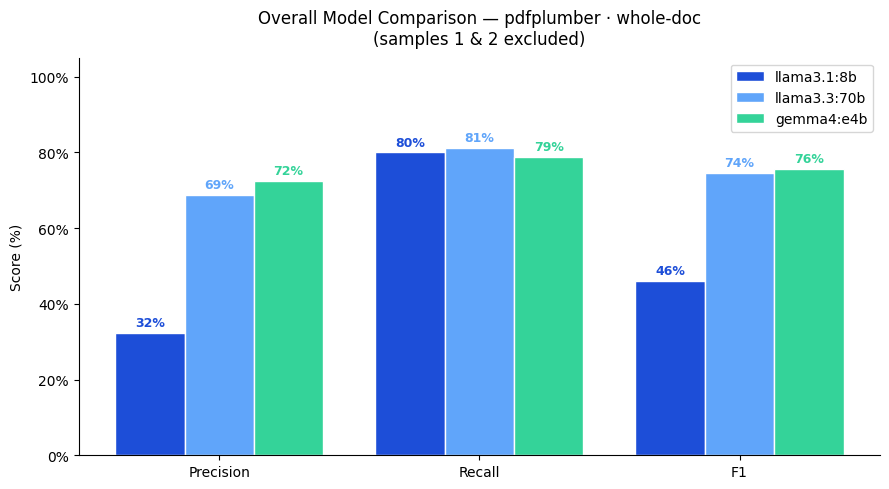

In [3]:
COLORS = ['#1d4ed8', '#60a5fa', '#34d399']
metrics = ['precision', 'recall', 'f1']
metric_labels = ['Precision', 'Recall', 'F1']

n_models = len(summary)
w = 0.8 / n_models
xi = range(len(metrics))

fig, ax = plt.subplots(figsize=(9, 5))
for i, (name, color) in enumerate(zip(summary.index, COLORS[:n_models])):
    offset = (i - n_models / 2 + 0.5) * w
    vals = [summary.loc[name, m] * 100 for m in metrics]
    bars = ax.bar([x + offset for x in xi], vals, width=w,
                  label=name, color=color, edgecolor='white')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f'{v:.0f}%',
                ha='center', va='bottom', fontsize=9, fontweight='bold', color=color)

ax.set_xticks(list(xi))
ax.set_xticklabels(metric_labels)
ax.set_ylim(0, 105)
ax.set_ylabel('Score (%)')
ax.set_title('Overall Model Comparison — pdfplumber · whole-doc\n(samples 1 & 2 excluded)', pad=10)
ax.legend(loc='upper right')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0f}%'))
sns.despine()
plt.tight_layout()
plt.show()

## Detail: F1 Score per Label

Label                        llama3.1:8b   llama3.3:70b     gemma4:e4b
----------------------------------------------------------------------
title                             100.0%         100.0%          93.3%
section.title                      74.0%          75.7%          75.4%
section.description                33.3%          57.1%          40.0%
question.text                       2.5%           0.0%          50.0%
answer.text                        51.1%          80.5%          84.9%


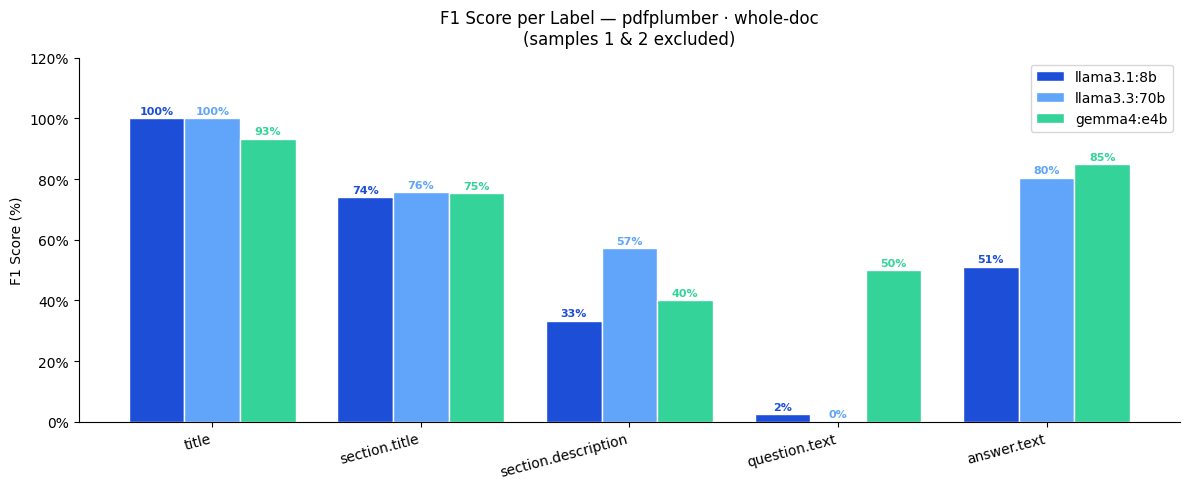

In [4]:
COLORS = ['#1d4ed8', '#60a5fa', '#34d399']

f1_data = {}
for name, res in results.items():
    f1_data[name] = compute_f1_rows(res['conf']).set_index('label')['f1']

df_f1 = pd.DataFrame(f1_data) * 100

# Table
print(f"{'Label':<25}" + ''.join(f'{n:>15}' for n in df_f1.columns))
print('-' * (25 + 15 * len(df_f1.columns)))
for label, row in df_f1.iterrows():
    print(f'{label:<25}' + ''.join(f'{v:>14.1f}%' for v in row))

# Bar chart
n_models = len(df_f1.columns)
n_labels = len(df_f1)
w = 0.8 / n_models
xi = range(n_labels)

fig, ax = plt.subplots(figsize=(12, 5))
for i, (name, color) in enumerate(zip(df_f1.columns, COLORS[:n_models])):
    offset = (i - n_models / 2 + 0.5) * w
    bars = ax.bar([x + offset for x in xi], df_f1[name], width=w,
                  label=name, color=color, edgecolor='white')
    for bar, val in zip(bars, df_f1[name]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.8,
                f'{val:.0f}%', ha='center', va='bottom', fontsize=8,
                fontweight='bold', color=color)

ax.set_xticks(list(xi))
ax.set_xticklabels(df_f1.index, rotation=15, ha='right')
ax.set_ylim(0, 120)
ax.set_ylabel('F1 Score (%)')
ax.set_title('F1 Score per Label — pdfplumber · whole-doc\n(samples 1 & 2 excluded)', pad=10)
ax.legend(loc='upper right')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0f}%'))
sns.despine()
plt.tight_layout()
plt.show()

## Detail: Confusion Matrix per Model
Rows = true label · Columns = predicted label

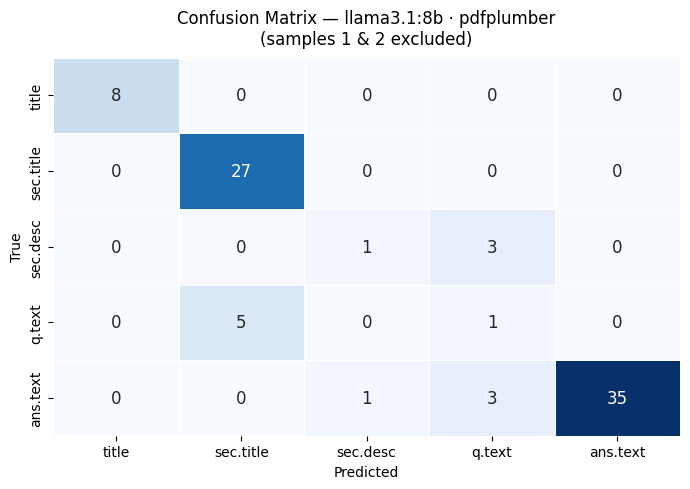

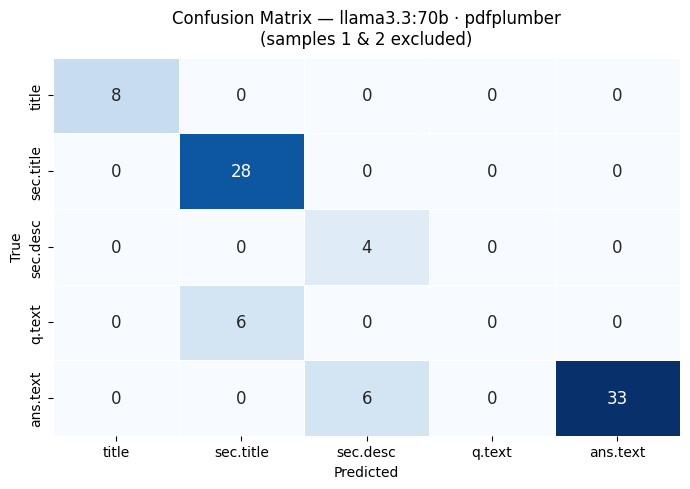

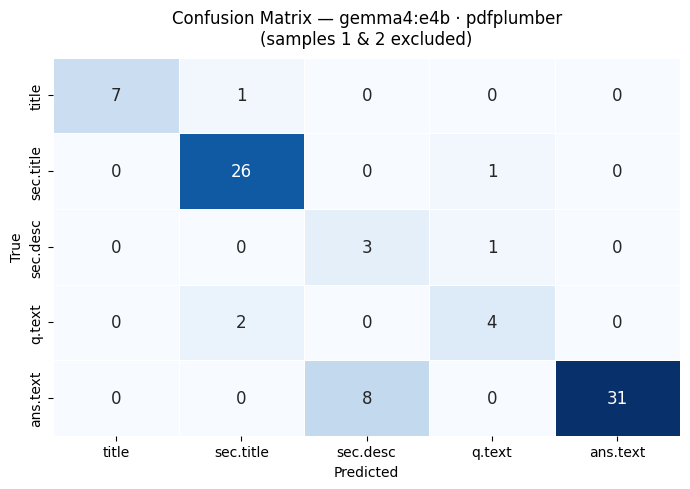

In [5]:
for name, res in results.items():
    mat = confusion_matrix_df(res['conf']).drop(columns=['missed'])

    fig, ax = plt.subplots(figsize=(7, 5))
    sns.heatmap(mat, annot=True, fmt='d', cmap='Blues',
                linewidths=0.5, linecolor='white',
                ax=ax, cbar=False, annot_kws={'size': 12})
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    ax.set_title(f'Confusion Matrix — {name} · pdfplumber\n(samples 1 & 2 excluded)', pad=10)
    plt.tight_layout()
    plt.show()